# Volleyball - Q-learning


In [7]:
import tkinter as tk
import threading
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

SEED = 42
random.seed(SEED)
np.random.seed(SEED)


In [8]:
# Environment and UI constants (same as Q-learning)
ROWS, COLS = 5, 9
CELL = 80
START = (2, 1)
OUTCOME = (2, 7)
ACTION_COL = 4
ACTION_ROWS = { 'pass': 0, 'emergency': 1, 'dump': 2, 'quick': 3, 'high': 4 }
MOVES = ['right','down','left','up']
ROW_OPTIONS = ['front','back']
PASS_OPTIONS = ['good','bad']
BLOCK_OPTIONS = ['blockers','noblockers']

def is_action_tile(r,c):
    return c == ACTION_COL and r in ACTION_ROWS.values()

def action_from_rc(r,c):
    if c != ACTION_COL: return None
    for name, rr in ACTION_ROWS.items():
        if rr == r: return name
    return None

def legal_action(row, pass_quality, action):
    if action == 'dump' and row == 'back':
        return False
    if pass_quality == 'good':
        return action in {'high','quick','dump','pass'} if row=='front' else action in {'high','quick','pass'}
    else:
        return action in {'emergency','dump','pass'} if row=='front' else action in {'emergency','pass'}

def success_probability(row, pass_quality, blockers, action):
    probs = { 'high':0.5, 'quick':0.5, 'dump':0.3, 'emergency':0.4, 'pass':0.0 }
    if pass_quality == 'bad':
        if row == 'back':
            if blockers == 'blockers':
                probs['emergency'] = 0.25
            else:
                probs['emergency'] = 0.55
        else:
            if blockers == 'blockers':
                probs['emergency'] = 0.6; probs['dump'] = 0.25
            else:
                probs['dump'] = 0.8; probs['emergency'] = 0.5
    else:
        if blockers == 'blockers':
            probs['quick'] = 0.65; probs['high']  = 0.65
            if row=='front': probs['dump'] = 0.4
        else:
            probs['quick'] = 0.85; probs['high']  = 0.85
            if row=='front': probs['dump'] = 0.8
    return probs.get(action, 0.0)

# CHANGED: reduced step penalty
STEP_PENALTY = -0.005
ILLEGAL_PENALTY = -1.0
SECOND_DECISION_PENALTY = -1.0
REVISIT_SAME_DECISION_PENALTY = -0.5
NO_ACTION_AT_GOAL = -0.5
PASS_REWARD = -0.2
EMERGENCY_WHEN_GOOD = -0.3

ACTIONS_LIST = [None, 'pass','emergency','dump','quick','high']

def move_pos(r,c,move):
    if move=='up':    return max(0,r-1), c
    if move=='down':  return min(ROWS-1,r+1), c
    if move=='left':  return r, max(0,c-1)
    if move=='right': return r, min(COLS-1,c+1)
    return r,c

def transitions(s, a):
    r,c,row,pq,bl,chosen = s
    nr,nc = move_pos(r,c,a)
    reward = STEP_PENALTY
    done = False
    next_chosen = chosen
    if is_action_tile(nr,nc):
        act = action_from_rc(nr,nc)
        if chosen is None:
            if not legal_action(row,pq,act):
                reward += ILLEGAL_PENALTY; done = True
            else:
                next_chosen = act
        else:
            if act == chosen: reward += REVISIT_SAME_DECISION_PENALTY
            else: reward += SECOND_DECISION_PENALTY
    if (nr,nc) == OUTCOME and not done:
        if next_chosen is None: reward += NO_ACTION_AT_GOAL
        elif next_chosen == 'pass': reward += PASS_REWARD
        elif next_chosen == 'emergency' and pq=='good': reward += EMERGENCY_WHEN_GOOD
        else:
            p = success_probability(row,pq,bl,next_chosen); reward += 2*p - 1
        done = True
    ns = (nr,nc,row,pq,bl,next_chosen)
    return [(ns, 1.0, reward, done)]

def greedy_action_fallback(s):
    r, c, row, pq, bl, chosen = s
    target_c = ACTION_COL if chosen is None else OUTCOME[1]
    if c < target_c: return 'right'
    if c > target_c: return 'left'
    if chosen is None:
        action_rows = list(ACTION_ROWS.values())
        target_r = min(action_rows, key=lambda rr: abs(rr - r))
    else:
        target_r = OUTCOME[0]
    if r < target_r: return 'down'
    if r > target_r: return 'up'
    return 'right'

def reset_random_conditions():
    return random.choice(ROW_OPTIONS), random.choice(PASS_OPTIONS), random.choice(BLOCK_OPTIONS)

def step_sampled(s, a):
    ns, p, r, done = transitions(s, a)[0]
    if done and (ns[0], ns[1]) == OUTCOME:
        row, pq, bl, chosen = ns[2], ns[3], ns[4], ns[5]
        if chosen not in (None, 'pass'):
            prob = success_probability(row, pq, bl, chosen)
            r = 1.0 if random.random() < prob else -1.0
    return ns, r, done


In [ ]:
# Q-learning with slower epsilon decay
class QLearner:
    def __init__(self, alpha=0.2, gamma=0.95, eps_start=0.4, eps_end=0.05, episodes=40000):
        self.alpha = alpha; self.gamma = gamma
        self.eps_start = eps_start; self.eps_end = eps_end; self.episodes = episodes
        self.Q = defaultdict(lambda: defaultdict(float))

    def policy(self, s, eps):
        if random.random() < eps:
            if random.random() < 0.5: return greedy_action_fallback(s)
            return random.choice(MOVES)
        if self.Q[s]: return max(MOVES, key=lambda a: self.Q[s].get(a, 0.0))
        return greedy_action_fallback(s)

    def train(self, progress_cb=None):
        eps = self.eps_start
        for ep in range(1, self.episodes+1):
            eps = self.eps_end + (self.eps_start - self.eps_end) * max(0, (self.episodes - ep)) / self.episodes
            row,pq,bl = reset_random_conditions()
            s = (START[0], START[1], row, pq, bl, None)
            steps = 0; done = False
            while not done and steps < 200:
                a = self.policy(s, eps)
                ns, r, done = step_sampled(s, a)
#! QLEARNING ALGORITHM MATH
                max_next = max((self.Q[ns].get(a2,0.0) for a2 in MOVES), default=0.0)
                self.Q[s][a] += self.alpha * (r + (0.0 if done else self.gamma * max_next) - self.Q[s][a])
                s = ns; steps += 1
            if progress_cb and ep % 500 == 0: progress_cb(ep)
        return self.Q

def V_from_Q(Q):
    V = defaultdict(float)
    for s in Q.keys(): V[s] = max((Q[s].get(a,0.0) for a in MOVES), default=0.0)
    return V

def greedy_from_Q(Q):
    def pi(s): return max(MOVES, key=lambda a: Q[s].get(a,0.0)) if Q[s] else greedy_action_fallback(s)
    return pi


In [10]:
# Plotting helpers (same)
def grid_values_for(V, row, pq, bl, chosen=None):
    M = np.zeros((ROWS, COLS), dtype=float)
    for r in range(ROWS):
        for c in range(COLS):
            s = (r, c, row, pq, bl, chosen)
            M[r, c] = V.get(s, 0.0)
    return M

def plot_state_values_all_from_V(V):
    combos = [
        ('front','good','blockers'), ('front','good','noblockers'),
        ('front','bad','blockers'),  ('front','bad','noblockers'),
        ('back','good','blockers'),  ('back','good','noblockers'),
        ('back','bad','blockers'),   ('back','bad','noblockers'),
    ]
    mats = [grid_values_for(V, row, pq, bl, chosen=None) for (row, pq, bl) in combos]
    all_vals = np.concatenate([m.flatten() for m in mats])
    vmin, vmax = float(np.min(all_vals)), float(np.max(all_vals))
    if vmin == vmax: vmin, vmax = vmin-1e-6, vmax+1e-6
    fig, axes = plt.subplots(2, 4, figsize=(18, 8), constrained_layout=True)
    axes = axes.ravel()
    for ax, (row, pq, bl), M in zip(axes, combos, mats):
        im = ax.imshow(M, cmap='coolwarm', vmin=vmin, vmax=vmax, origin='upper', interpolation='nearest')
        ax.set_title(f'{row}, {pq}, {bl}')
        ax.set_xticks(range(COLS)); ax.set_yticks(range(ROWS))
        ax.scatter([START[1]], [START[0]], s=80, c='lime', marker='s', edgecolors='k')
        ax.scatter([OUTCOME[1]], [OUTCOME[0]], s=80, c='yellow', marker='*', edgecolors='k')
    cbar = fig.colorbar(im, ax=axes.tolist(), shrink=0.9); cbar.set_label('V(s)')
    plt.show()


In [ ]:
# App (unchanged UI)
class QLearningApp:
    def __init__(self):
        self.root = tk.Tk(); self.root.title('Q-learning Control — SlowEps Variant')
        self.canvas = tk.Canvas(self.root, width=COLS*CELL, height=ROWS*CELL, bg='white'); self.canvas.pack()
        self.status = tk.Label(self.root, text='Ready', anchor='w'); self.status.pack(fill='x')
        self.cond_label = tk.Label(self.root, text='Conditions: —', anchor='w'); self.cond_label.pack(fill='x')
        ctl = tk.Frame(self.root); ctl.pack(fill='x')
        self.train_btn = tk.Button(ctl, text='Train', command=self.start_training, bg='#2e7d32', fg='white'); self.train_btn.pack(side='left', padx=5)
        self.test_btn  = tk.Button(ctl, text='Test Policy', command=self.start_testing, bg='#1565c0', fg='white'); self.test_btn.pack(side='left', padx=5)
        self.demo_btn  = tk.Button(ctl, text='Run Demo', command=self.start_demo, bg='#ef6c00', fg='white'); self.demo_btn.pack(side='left', padx=5)
        self.stop_btn  = tk.Button(ctl, text='Stop Demo', command=self.stop_demo, bg='#b71c1c', fg='white'); self.stop_btn.pack(side='left', padx=5)
        tk.Label(ctl, text='Speed (ms/step)').pack(side='left', padx=(20,4))
        self.speed = tk.Scale(ctl, from_=0, to=800, orient='horizontal'); self.speed.set(200); self.speed.pack(side='left')
        tk.Label(ctl, text='Episodes').pack(side='left', padx=(20,4))
        self.num_episodes = tk.IntVar(value=300)
        self.ep_entry = tk.Spinbox(ctl, from_=1, to=10000, textvariable=self.num_episodes, width=6); self.ep_entry.pack(side='left')
        self.graph_btn = tk.Button(ctl, text='Compute Graphs', command=self.show_graphs, bg='#6a1b9a', fg='white'); self.graph_btn.pack(side='left', padx=5)
        self.draw_board(); self.agent_token=None
        self.episode_rewards = []; self.cumulative_rewards = []
        self.running_demo=False; self.demo_state=None; self.demo_steps=0
        # CHANGED: longer training with slower epsilon decay
        self.learner = QLearner(alpha=0.2, gamma=0.95, eps_start=0.4, eps_end=0.05, episodes=40000)
        self.V = {}; self.Q = None

    def draw_board(self):
        self.canvas.delete('all')
        for r in range(ROWS):
            for c in range(COLS):
                x1,y1 = c*CELL, r*CELL; x2,y2 = x1+CELL, y1+CELL
                fill='white'
                if (r,c)==START: fill='#c8e6c9'
                if (r,c)==OUTCOME: fill='#ffcdd2'
                if is_action_tile(r,c): fill='#fff9c4'
                self.canvas.create_rectangle(x1,y1,x2,y2, fill=fill, outline='black')
                if is_action_tile(r,c):
                    name=action_from_rc(r,c)
                    self.canvas.create_text(x1+CELL/2, y1+CELL/2, text=name.title(), font=('Arial',11,'bold'))
        self.canvas.create_text(START[1]*CELL+CELL/2, START[0]*CELL+12, text='START', fill='green')
        self.canvas.create_text(OUTCOME[1]*CELL+CELL/2, OUTCOME[0]*CELL+12, text='OUTCOME', fill='red')

    def draw_agent(self, r, c):
        x1, y1 = c*CELL+12, r*CELL+12; x2, y2 = x1+CELL-24, y1+CELL-24
        if self.agent_token is None: self.agent_token = self.canvas.create_oval(x1,y1,x2,y2, fill='#1f6feb', outline='black')
        else: self.canvas.coords(self.agent_token, x1, y1, x2, y2)

    def start_training(self):
        self.status.config(text='Training Q-learning (slow eps)...'); self.train_btn.config(state='disabled')
        def work():
            self.Q = self.learner.train()
            self.V = V_from_Q(self.Q)
            self.root.after(0, self.training_done)
        threading.Thread(target=work, daemon=True).start()

    def training_done(self):
        self.status.config(text='Training complete. Use Test Policy or Compute Graphs.'); self.train_btn.config(state='normal')

    def start_testing(self):
        if not self.Q: self.status.config(text='Train first.'); return
        self.episode_rewards.clear(); self.cumulative_rewards.clear()
        self.status.config(text='Testing (running episodes) ...')
        act_policy = greedy_from_Q(self.Q)
        def work():
            total=0.0; episodes=max(1,int(self.num_episodes.get()))
            for ep in range(episodes):
                row,pq,bl = reset_random_conditions()
                self.root.after(0, lambda e=ep,cond=(row,pq,bl),n=episodes: self.cond_label.config(text=f'Conditions (test ep {e+1}/{n}): {cond[2]}, {cond[1]}, {cond[0]}'))
                s=(START[0],START[1],row,pq,bl,None); rsum=0.0; steps=0; done=False
                while not done and steps<200:
                    a=act_policy(s); ns,r,done=step_sampled(s,a); rsum+=r; s=ns; steps+=1
                total+=rsum; self.episode_rewards.append(rsum); self.cumulative_rewards.append(total)
                if (ep+1)%100==0: print(f'Episode {ep+1}: avg reward (last 100) = {np.mean(self.episode_rewards[-100:]):.3f}')
            self.root.after(0, lambda: self.status.config(text='Testing complete. Click Compute Graphs.'))
        threading.Thread(target=work, daemon=True).start()

    def start_demo(self):
        if not self.Q: self.status.config(text='Train first to get a policy.'); return
        if self.running_demo: return
        self.running_demo=True
        self.demo_state=(START[0],START[1],*reset_random_conditions(),None); self.demo_steps=0
        row,pq,bl=self.demo_state[2],self.demo_state[3],self.demo_state[4]
        self.status.config(text='Demo start'); self.cond_label.config(text=f'Conditions: {bl}, {pq}, {row}')
        self.draw_agent(self.demo_state[0], self.demo_state[1]); self.schedule_demo_step()

    def stop_demo(self): self.running_demo=False; self.status.config(text='Demo stopped.')

    def schedule_demo_step(self):
        if not self.running_demo: return
        if self.demo_steps>400:
            self.demo_state=(START[0],START[1],*reset_random_conditions(),None); self.demo_steps=0
            row,pq,bl=self.demo_state[2],self.demo_state[3],self.demo_state[4]
            self.status.config(text='Demo start (step cap)'); self.cond_label.config(text=f'Conditions: {bl}, {pq}, {row}')
            self.draw_agent(self.demo_state[0], self.demo_state[1])
        s=self.demo_state; act_policy=greedy_from_Q(self.Q); a=act_policy(s); ns,r,done=step_sampled(s,a)
        if (ns[0],ns[1])==(s[0],s[1]):
            for alt in ['right','down','left','up']:
                nr_alt,nc_alt=move_pos(s[0],s[1],alt)
                if (nr_alt,nc_alt)!=(s[0],s[1]):
                    ns2,r2,done2=step_sampled(s,alt)
                    if (ns2[0],ns2[1])!=(s[0],s[1]): ns,r,done,a=ns2,r2,done2,alt; break
        self.demo_state=ns; self.demo_steps+=1; self.draw_agent(ns[0],ns[1])
        chosen=ns[5]; self.status.config(text=f'Move: {a}, Reward: {r:.2f}' + (f', Chosen: {chosen}' if chosen else ''))
        delay_ms=int(self.speed.get());
        if done:
            self.demo_state=(START[0],START[1],*reset_random_conditions(),None); self.demo_steps=0
            row,pq,bl=self.demo_state[2],self.demo_state[3],self.demo_state[4]
            self.status.config(text='Demo start (prev terminal)'); self.cond_label.config(text=f'Conditions: {bl}, {pq}, {row}')
            self.draw_agent(self.demo_state[0], self.demo_state[1])
        self.root.after(max(0,delay_ms), self.schedule_demo_step)

    def show_graphs(self):
        if self.episode_rewards:
            plt.figure(figsize=(10,6)); plt.plot(self.episode_rewards, label='Reward per Episode')
            if len(self.episode_rewards)>20:
                w=50 if len(self.episode_rewards)>=50 else max(5,len(self.episode_rewards)//5)
                ma=np.convolve(self.episode_rewards, np.ones(w)/w, mode='valid')
                plt.plot(range(w-1,len(self.episode_rewards)), ma, 'r-', label=f'MA({w})')
            plt.xlabel('Episode'); plt.ylabel('Reward'); plt.title('Reward vs Episode'); plt.grid(True); plt.legend(); plt.show()
        if self.cumulative_rewards:
            plt.figure(figsize=(10,6)); plt.plot(self.cumulative_rewards)
            plt.xlabel('Episode'); plt.ylabel('Cumulative Reward'); plt.title('Cumulative Reward vs Episode'); plt.grid(True); plt.show()
        if self.V: plot_state_values_all_from_V(self.V)

    def run(self): self.root.mainloop()


## Run App: Q-learning Control (SlowEps)
Use Train → Test Policy → Compute Graphs, and Run Demo/Stop Demo as in the original notebook.

Episode 100: avg reward (last 100) = -0.439
Episode 200: avg reward (last 100) = -0.281
Episode 300: avg reward (last 100) = -0.400


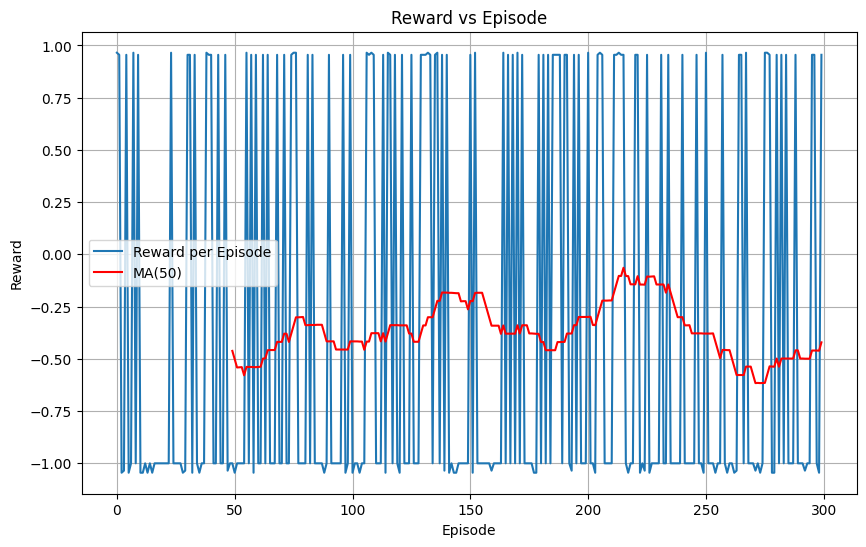

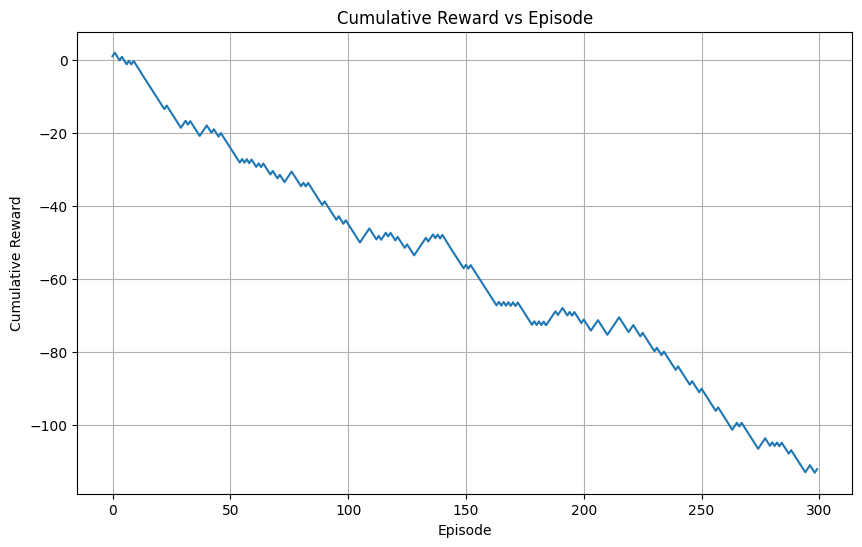

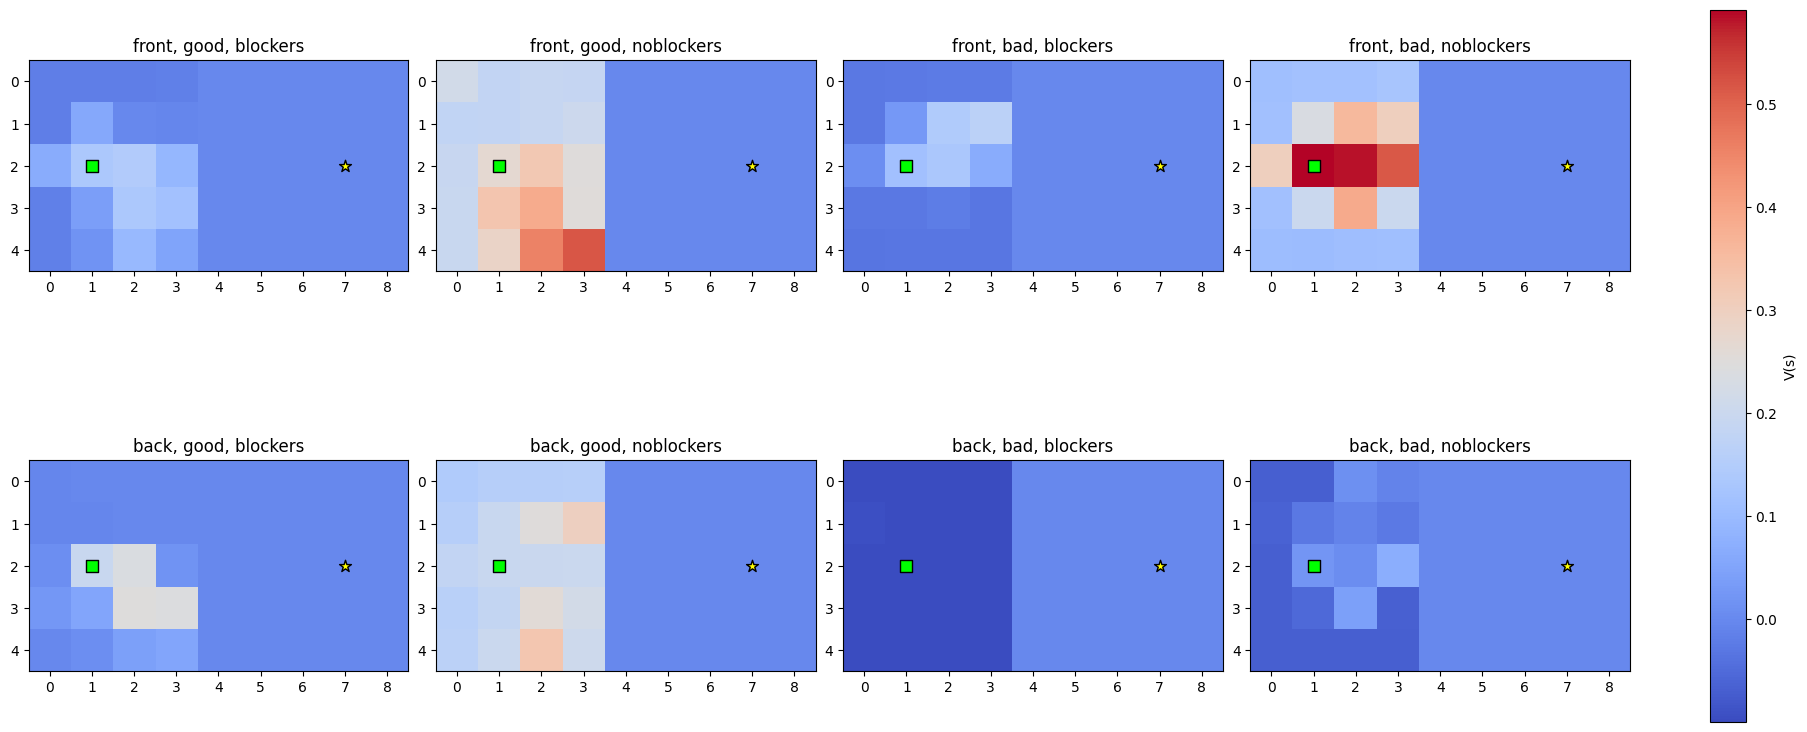

In [12]:
QLearningApp().run()
